### 1. Libraries

In [1]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

In [19]:
# Set option to display all columns
pd.set_option('display.max_columns', None)



### 2. Loading Datasets

In [2]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")

#### 3. Data Wrangling

#### 3.1 Structure Check

**Data Type and Dimension**

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [9]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254655 entries, 0 to 254654
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                254655 non-null  int64  
 1   gender            254655 non-null  object 
 2   SeniorCitizen     254655 non-null  int64  
 3   Partner           254655 non-null  object 
 4   Dependents        254655 non-null  object 
 5   tenure            254655 non-null  int64  
 6   PhoneService      254655 non-null  object 
 7   MultipleLines     254655 non-null  object 
 8   InternetService   254655 non-null  object 
 9   OnlineSecurity    254655 non-null  object 
 10  OnlineBackup      254655 non-null  object 
 11  DeviceProtection  254655 non-null  object 
 12  TechSupport       254655 non-null  object 
 13  StreamingTV       254655 non-null  object 
 14  StreamingMovies   254655 non-null  object 
 15  Contract          254655 non-null  object 
 16  PaperlessBilling  25

Comment: There is no missing value. The test dataset does not contain the target variable, so the train dataset shall be split during the cross validation step. The "id" column shall be dropoped since it does not offer any signal.

In [ ]:
df_train = df_train.drop(columns=['id'])
df_test = df_test.drop(columns=['id'])

**Duplicate Rows**

In [9]:
print("Duplicate rows:", df_train.duplicated().sum())
print("Duplicate rows:", df_test.duplicated().sum())

Duplicate rows: 0
Duplicate rows: 0


### 3.2. Column Check

#### 3.2.1. Column Type Classification

**Sample Inputs**

In [10]:
df_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


**Unique Values**

In [12]:
for col in df_train.columns:
    print(f"{col}: {df_train[col].nunique()} unique values")

gender: 2 unique values
SeniorCitizen: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
tenure: 72 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values
MonthlyCharges: 1921 unique values
TotalCharges: 31910 unique values
Churn: 2 unique values


In [14]:
# Numerical columns
num_cols = ['MonthlyCharges', 'TotalCharges', 'tenure']  

**Categorical and Ordinal Variable Classification**

In [25]:
# Columns excluding numerical columns
cols = [col for col in df_train.columns if col not in num_cols]

for col in cols:
    print(f"\nColumn: {col}")
    print(df_train[col].unique())


Column: gender
['Male' 'Female']

Column: SeniorCitizen
[0 1]

Column: Partner
['Yes' 'No']

Column: Dependents
['Yes' 'No']

Column: PhoneService
['Yes' 'No']

Column: MultipleLines
['No' 'Yes' 'No phone service']

Column: InternetService
['DSL' 'Fiber optic' 'No']

Column: OnlineSecurity
['Yes' 'No' 'No internet service']

Column: OnlineBackup
['No' 'Yes' 'No internet service']

Column: DeviceProtection
['Yes' 'No' 'No internet service']

Column: TechSupport
['Yes' 'No' 'No internet service']

Column: StreamingTV
['No' 'Yes' 'No internet service']

Column: StreamingMovies
['No' 'Yes' 'No internet service']

Column: Contract
['One year' 'Two year' 'Month-to-month']

Column: PaperlessBilling
['Yes' 'No']

Column: PaymentMethod
['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']

Column: Churn
['No' 'Yes']


Comment:

Based on the input format of each of the column, the columns are classified as follows:

Numerical `num_cols`: ['MonthlyCharges', 'TotalCharges', 'tenure]

Ordinal: None

Categorical `cat_cols`: the rest

In [26]:
cat_cols = cols[:]
del cols 
target_col = cat_cols.pop()


#### 3.2.2. Numerical Column Check

**Outlier Detection**

In [20]:
# Train data
df_train.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057
std,0.317936,25.061922,31.067444,2353.916710
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,12.000000,29.900000,639.650000
50%,0.000000,35.000000,74.100000,1433.650000
75%,0.000000,62.000000,90.800000,4263.800000
max,1.000000,72.000000,118.750000,8684.800000


In [23]:
# Test data
df_test.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,254655.00000,254655.000000,254655.000000,254655.000000
mean,0.11362,37.279716,66.130803,2544.617351
std,0.31735,24.777625,31.104139,2348.124379
min,0.00000,1.000000,18.300000,18.800000
25%,0.00000,13.000000,30.150000,677.625000
50%,0.00000,36.000000,74.350000,1468.750000
75%,0.00000,62.000000,91.100000,4317.300000
max,1.00000,72.000000,118.750000,8684.800000


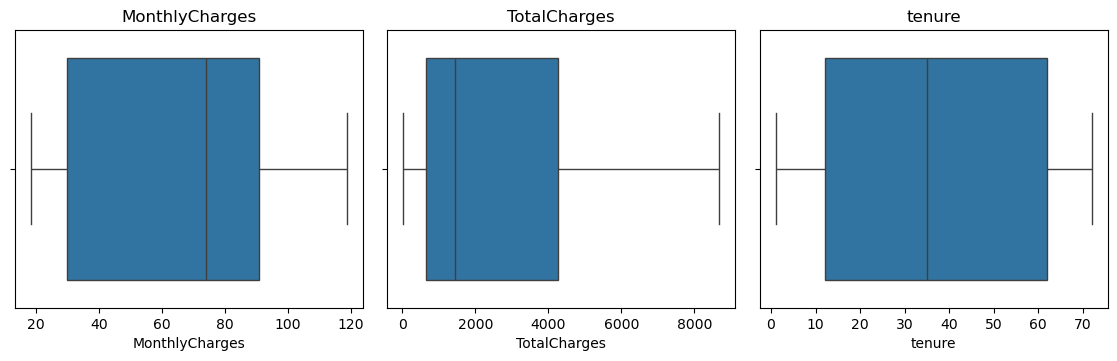

In [31]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols[:12], 1):  # limit to avoid clutter
    plt.subplot(3, 4, i)
    sns.boxplot(x=df_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Comment: The values of the numerical columns do not show abnormality. 

**Distribution**

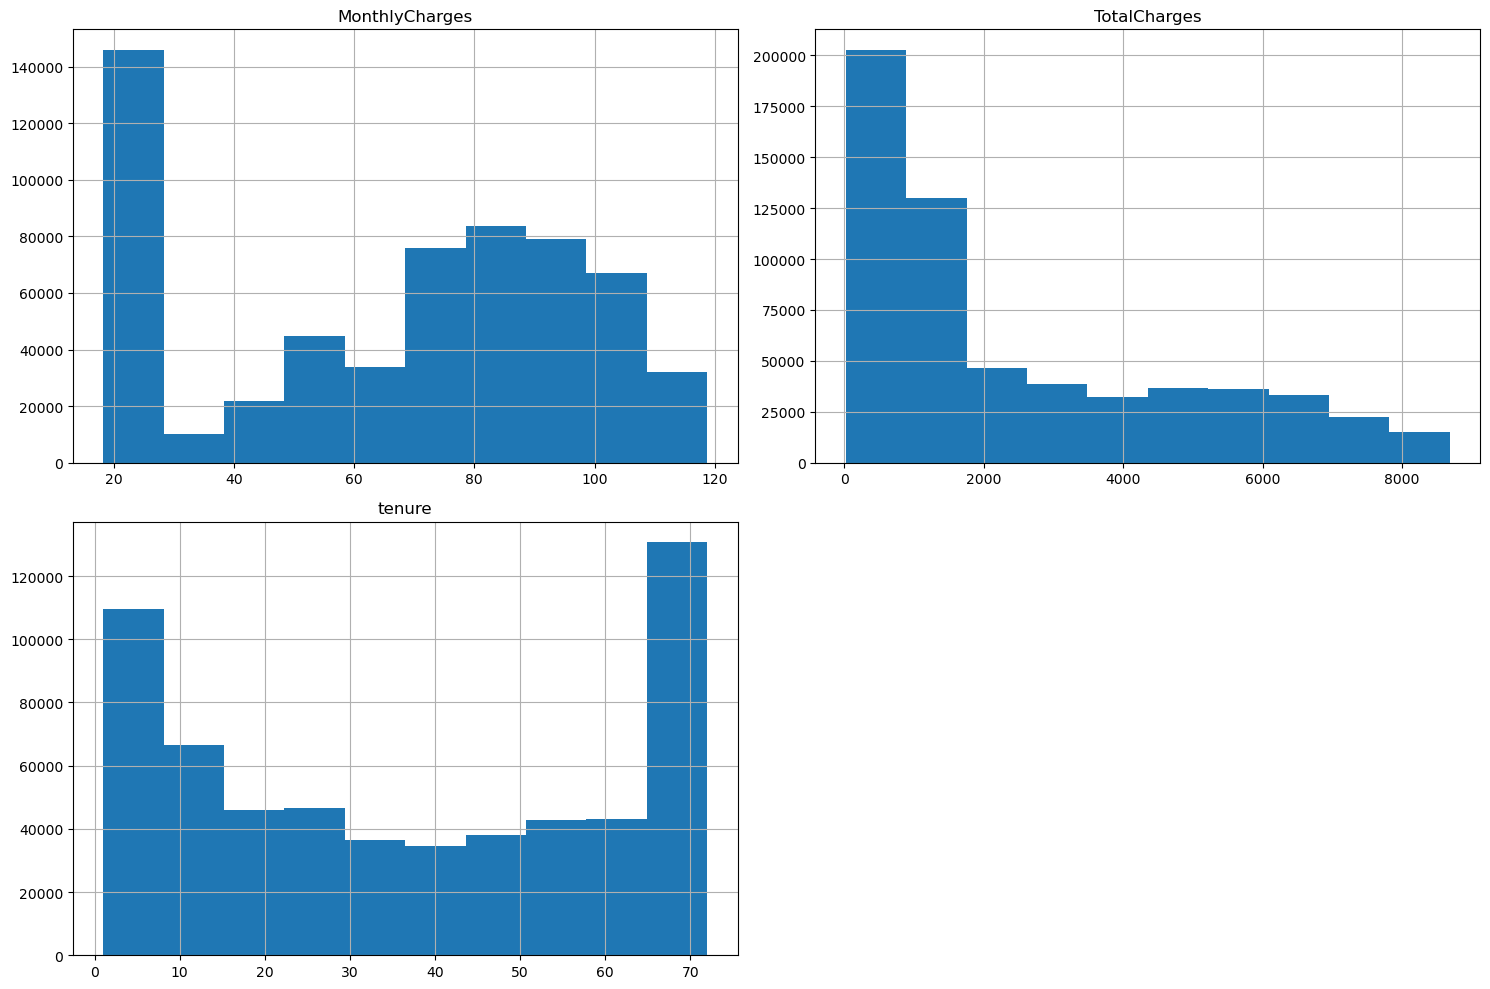

In [16]:
df_train[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

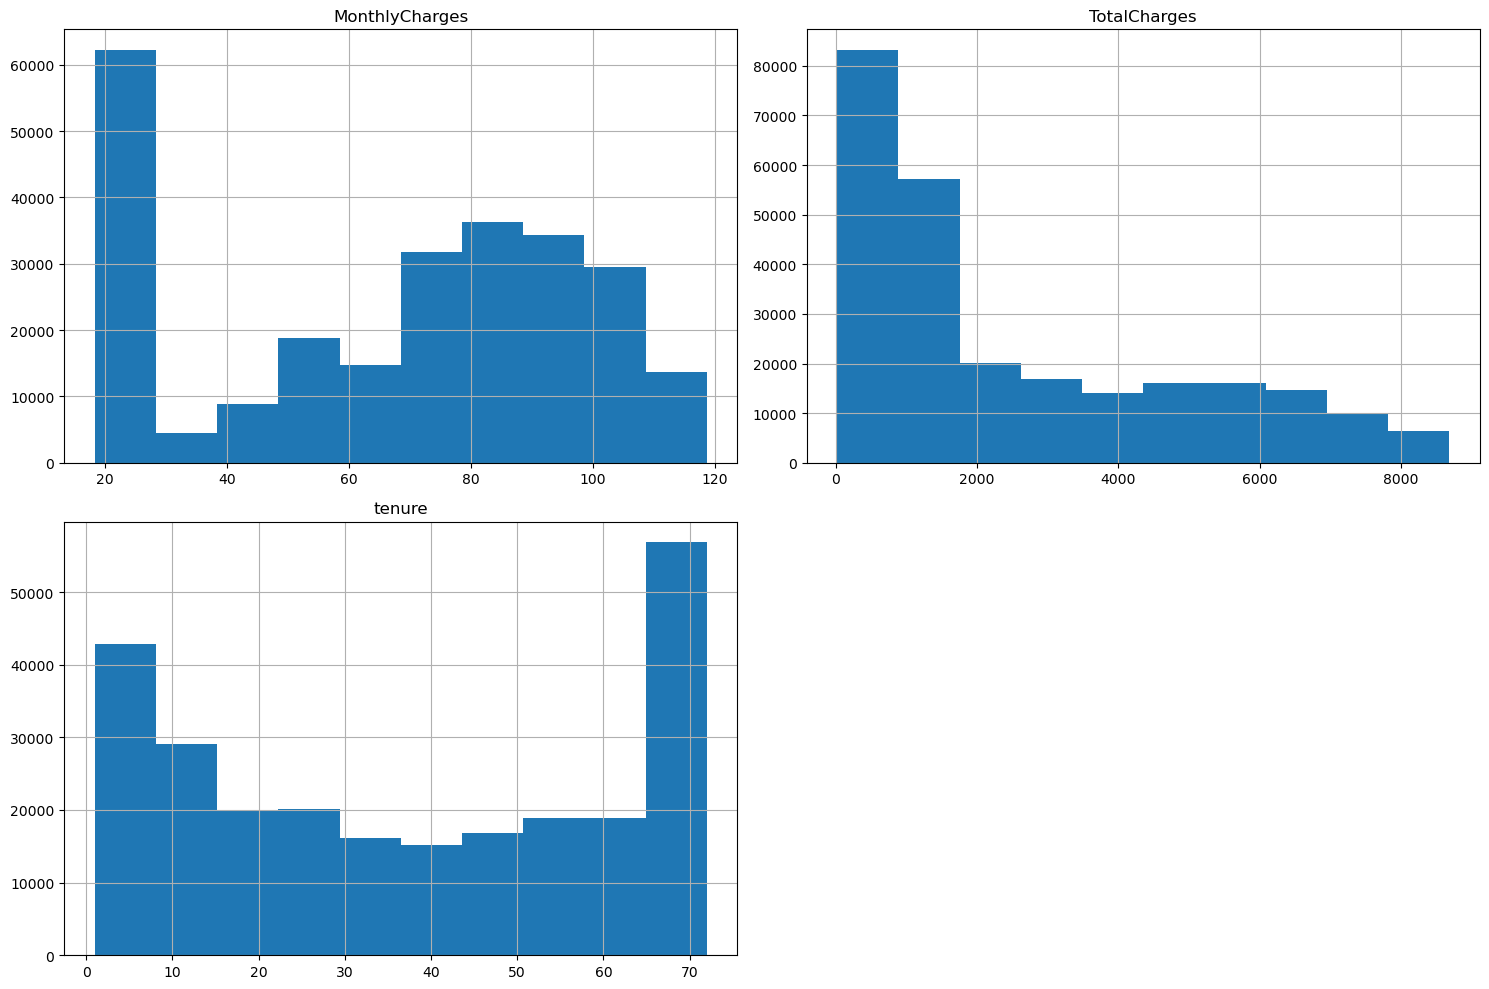

In [24]:
df_test[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

**Comment:** The distributions of numerical variables in the train and test datasets show similar structure. 

#### 3.2.3. Categorical Column Check

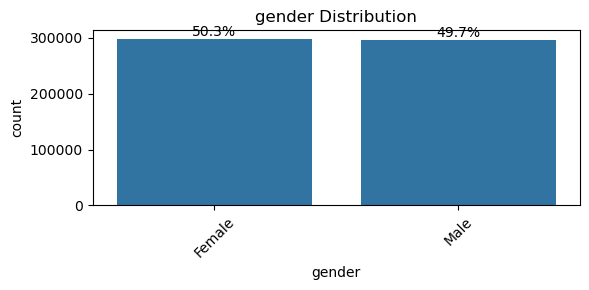

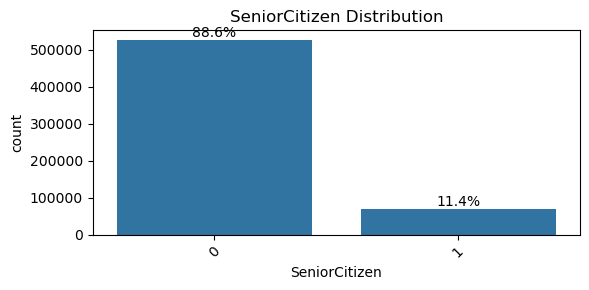

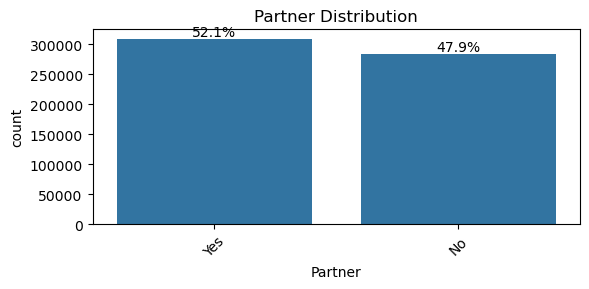

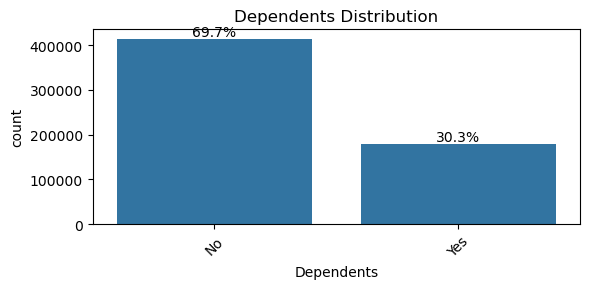

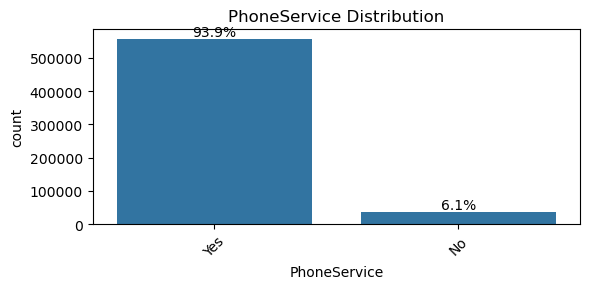

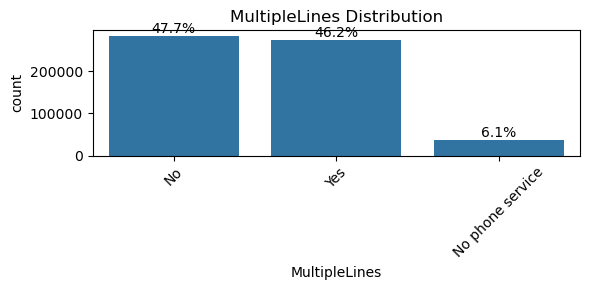

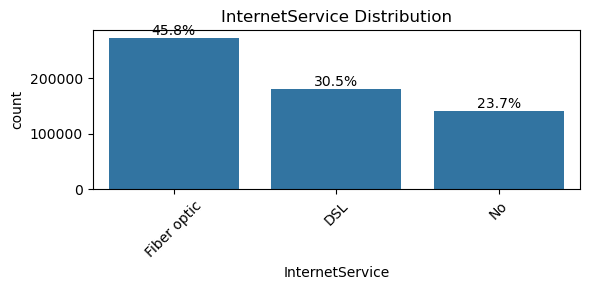

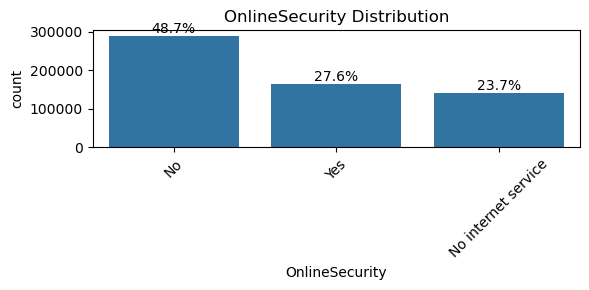

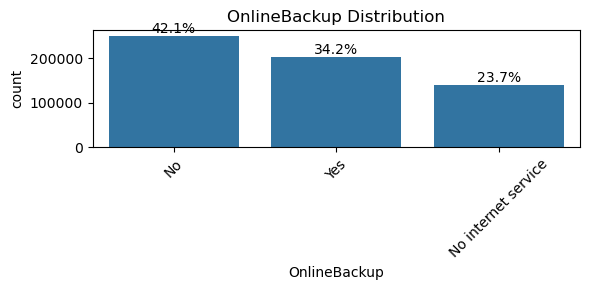

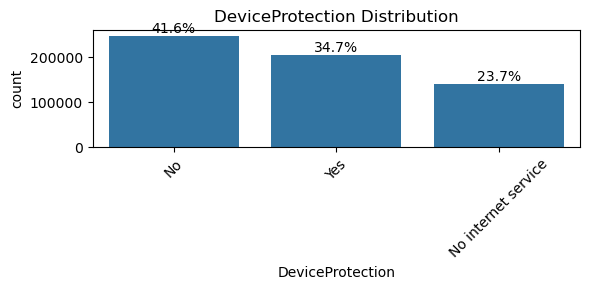

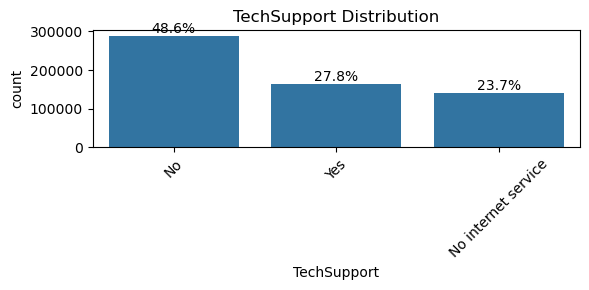

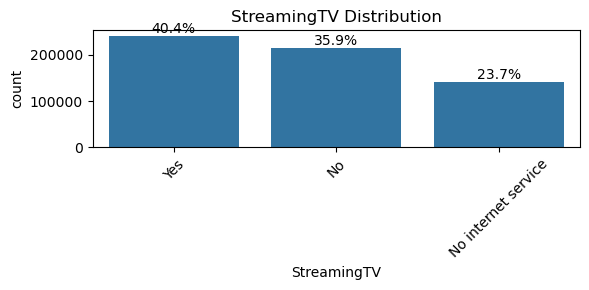

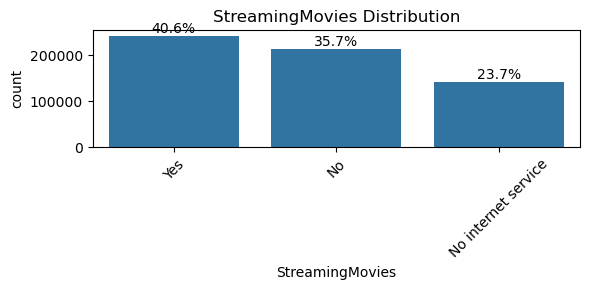

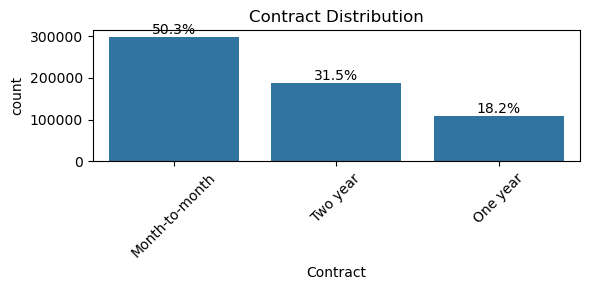

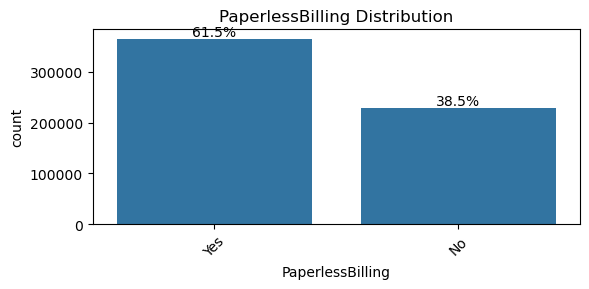

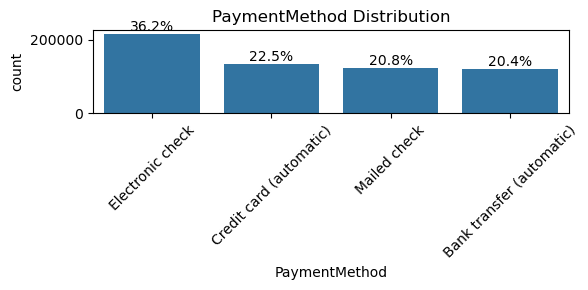

In [28]:
for col in cat_cols:
    plt.figure(figsize=(6, 3))
    
    ax = sns.countplot(data=df_train, x=col, order=df_train[col].value_counts().index)
    
    total = len(df_train)
    
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(percentage, 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom')
    
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### 3.2.2. Test Dataset

In [17]:
# Test data
df_test.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,254655.000000,254655.00000,254655.000000,254655.000000,254655.000000
mean,721521.000000,0.11362,37.279716,66.130803,2544.617351
std,73512.710738,0.31735,24.777625,31.104139,2348.124379
min,594194.000000,0.00000,1.000000,18.300000,18.800000
25%,657857.500000,0.00000,13.000000,30.150000,677.625000
50%,721521.000000,0.00000,36.000000,74.350000,1468.750000
75%,785184.500000,0.00000,62.000000,91.100000,4317.300000
max,848848.000000,1.00000,72.000000,118.750000,8684.800000


In [ ]:
# Box Plot, Numerical vs Target

for col in num_cols:
    plt.figure(figsize=(5, 3))
    
    sns.boxplot(data=df_train, x='Churn', y=col)
    
    plt.title(f"{col} vs Churn")
    plt.tight_layout()
    plt.show()